In [27]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [28]:
OPTIONS = json.loads(open('../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'dynamic_tests': 1, 'static_tests': 1}

In [29]:
TEST_NUM = OPTIONS['dynamic_tests']
PATH     = f'../files/test{TEST_NUM}'
PATH

'../files/test1'

In [30]:
TARGET_VAR  = 'pitch'
TARGET_TIME = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits') 
TARGET_TIME

[0, 1000000000.0]

# IMPORTANDO DADOS

In [31]:
df = pd.read_csv(f'{PATH}/reference/data.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,wx,wz,yaw,q1,sample_time,roll,az,q0,q2,la_pos_mon_d,time,wy,pitch,ax,q3,ay
0,0.000053,-0.000169,-0.7092,0.6589,905000000.0,1.559,-0.1157,0.6673,-0.2453,0.1645,0.000000,-0.000405,-0.003563,0.03940,-0.2457,-9.788
1,0.000075,0.000012,-0.7093,0.6589,5000000.0,1.559,-0.1158,0.6673,-0.2453,0.1647,0.043499,-0.000467,-0.003563,0.03912,-0.2458,-9.788
2,-0.000103,0.000024,-0.7093,0.6589,105000000.0,1.559,-0.1155,0.6673,-0.2453,0.1650,0.140979,-0.000428,-0.003567,0.03920,-0.2458,-9.788
3,0.000123,-0.000131,-0.7093,0.6589,205000000.0,1.559,-0.1155,0.6673,-0.2453,0.1652,0.247164,-0.000532,-0.003567,0.03921,-0.2458,-9.788
4,-0.000170,-0.000089,-0.7094,0.6588,305000000.0,1.559,-0.1157,0.6673,-0.2454,0.1655,0.348991,-0.000610,-0.003570,0.03936,-0.2458,-9.788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,0.000140,-0.000057,-0.7359,0.6553,805000000.0,1.559,-0.1144,0.6643,-0.2543,0.1323,66.856288,-0.000371,-0.004379,0.04202,-0.2544,-9.788
670,-0.000008,0.000139,-0.7360,0.6553,905000000.0,1.559,-0.1144,0.6642,-0.2543,0.1319,66.957086,-0.000446,-0.004387,0.04224,-0.2544,-9.788
671,-0.000356,0.000274,-0.7360,0.6552,5000000.0,1.559,-0.1142,0.6642,-0.2543,0.1316,67.063414,-0.000367,-0.004387,0.04215,-0.2545,-9.788
672,0.000230,-0.000146,-0.7361,0.6552,105000000.0,1.559,-0.1145,0.6642,-0.2543,0.1312,67.164494,-0.000320,-0.004383,0.04204,-0.2545,-9.788


- Convertendo pra radianos

In [32]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,wx,wz,yaw,q1,sample_time,roll,az,q0,q2,la_pos_mon_d,time,wy,pitch,ax,q3,ay
0,0.003031,-0.009672,-40.634167,0.6589,905000000.0,89.32412,-0.1157,0.6673,-0.2453,0.1645,0.000000,-0.023193,-0.204145,0.03940,-0.2457,-9.788
1,0.004274,0.000688,-40.639896,0.6589,5000000.0,89.32412,-0.1158,0.6673,-0.2453,0.1647,0.043499,-0.026769,-0.204145,0.03912,-0.2458,-9.788
2,-0.005924,0.001382,-40.639896,0.6589,105000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1650,0.140979,-0.024528,-0.204374,0.03920,-0.2458,-9.788
3,0.007053,-0.007534,-40.639896,0.6589,205000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1652,0.247164,-0.030487,-0.204374,0.03921,-0.2458,-9.788
4,-0.009752,-0.005117,-40.645626,0.6588,305000000.0,89.32412,-0.1157,0.6673,-0.2454,0.1655,0.348991,-0.034956,-0.204546,0.03936,-0.2458,-9.788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,0.008021,-0.003244,-42.163964,0.6553,805000000.0,89.32412,-0.1144,0.6643,-0.2543,0.1323,66.856288,-0.021251,-0.250898,0.04202,-0.2544,-9.788
670,-0.000432,0.007976,-42.169694,0.6553,905000000.0,89.32412,-0.1144,0.6642,-0.2543,0.1319,66.957086,-0.025531,-0.251357,0.04224,-0.2544,-9.788
671,-0.020426,0.015722,-42.169694,0.6552,5000000.0,89.32412,-0.1142,0.6642,-0.2543,0.1316,67.063414,-0.021056,-0.251357,0.04215,-0.2545,-9.788
672,0.013178,-0.008371,-42.175423,0.6552,105000000.0,89.32412,-0.1145,0.6642,-0.2543,0.1312,67.164494,-0.018346,-0.251127,0.04204,-0.2545,-9.788


# VISUALIZAÇÃO DE VARIÁVEIS

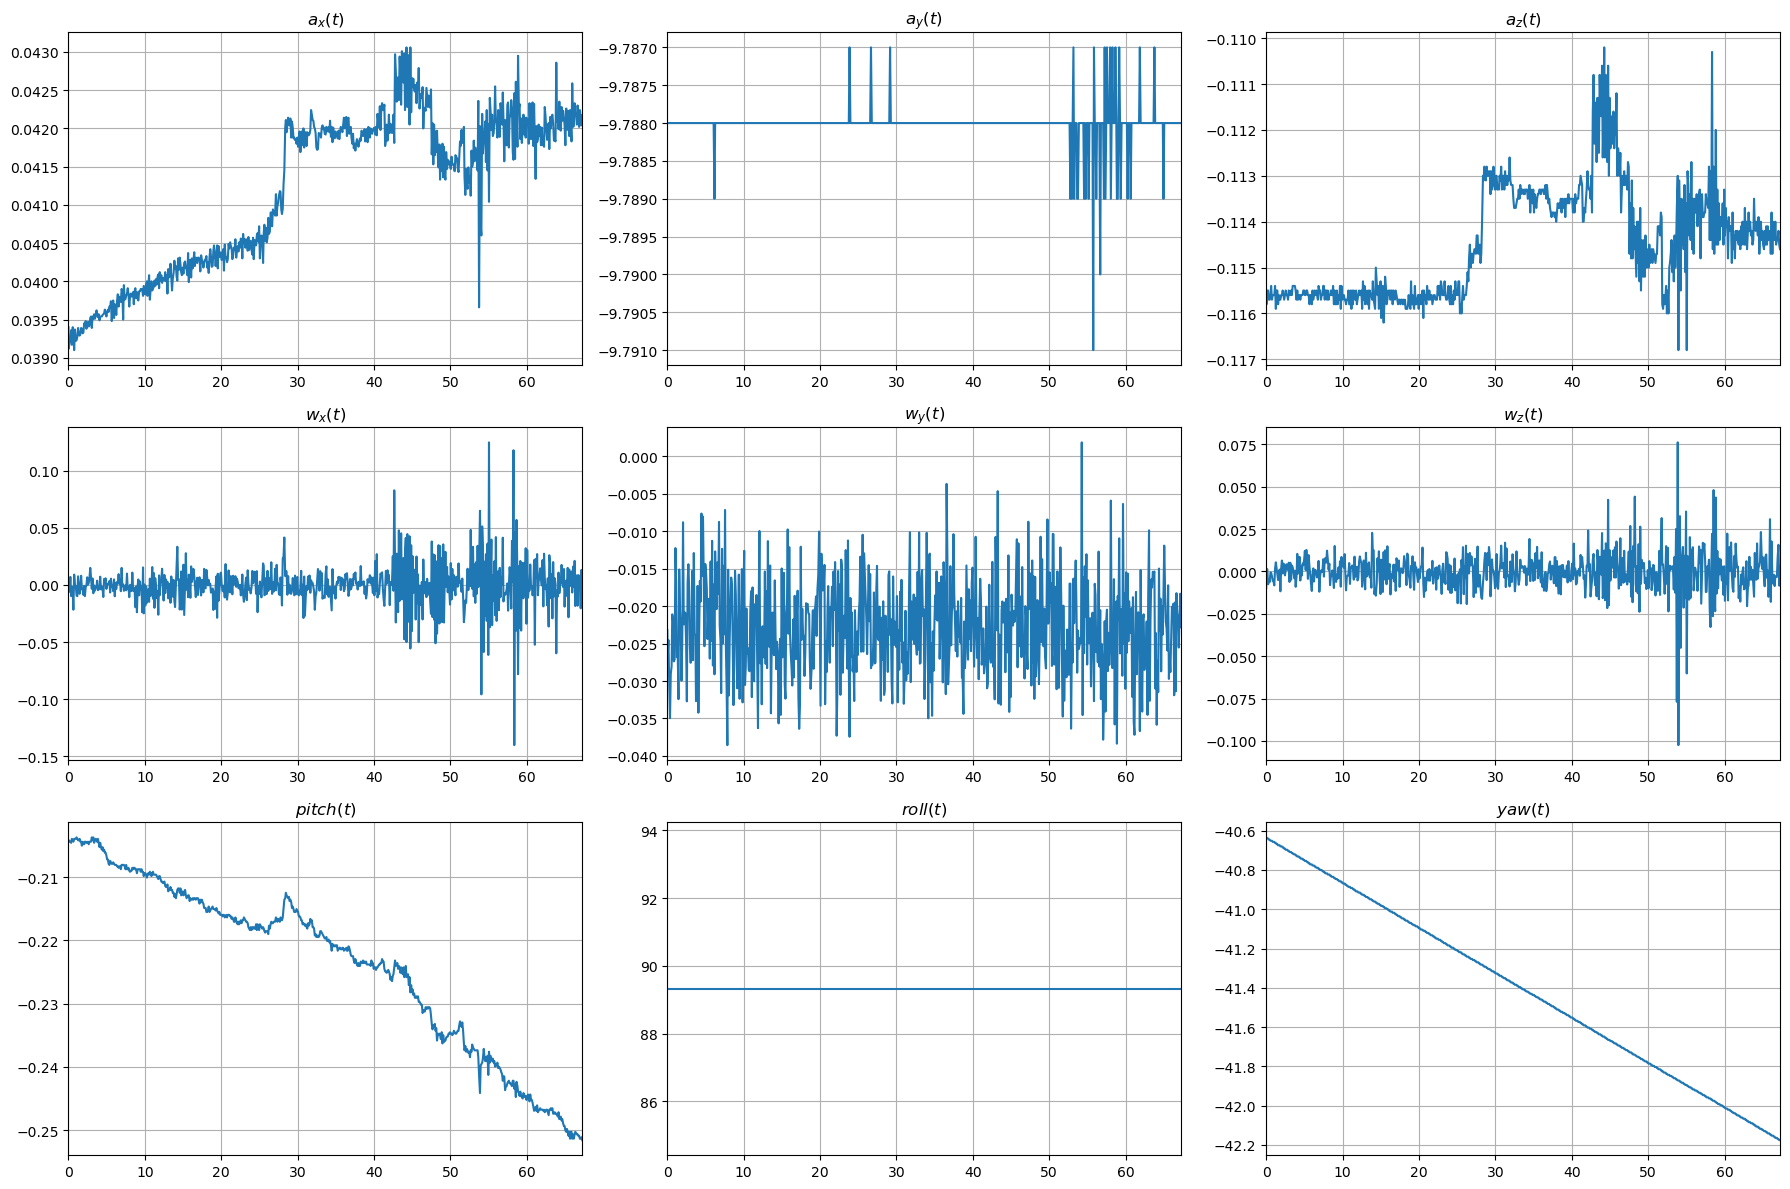

In [33]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

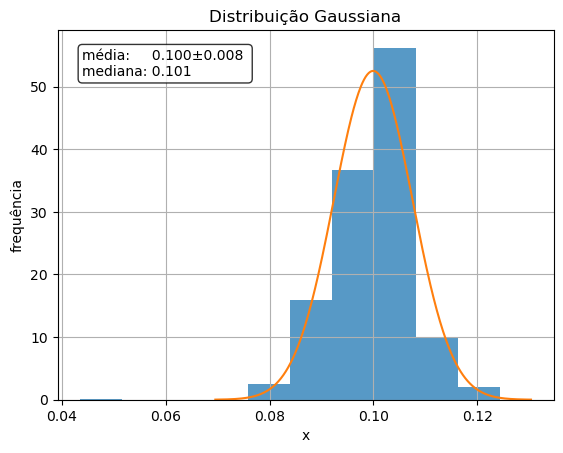

In [34]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [35]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,wx,wz,yaw,q1,sample_time,roll,az,q0,q2,la_pos_mon_d,wy,pitch,ax,q3,ay
0,0.0,0.003031,-0.009672,-40.634167,0.6589,905000000.0,89.32412,-0.1157,0.6673,-0.2453,0.1645,-0.023193,-0.204145,0.03940,-0.2457,-9.788
1,0.1,0.004274,0.000688,-40.639896,0.6589,5000000.0,89.32412,-0.1158,0.6673,-0.2453,0.1647,-0.026769,-0.204145,0.03912,-0.2458,-9.788
2,0.2,-0.005924,0.001382,-40.639896,0.6589,105000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1650,-0.024528,-0.204374,0.03920,-0.2458,-9.788
3,0.3,0.007053,-0.007534,-40.639896,0.6589,205000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1652,-0.030487,-0.204374,0.03921,-0.2458,-9.788
4,0.4,-0.009752,-0.005117,-40.645626,0.6588,305000000.0,89.32412,-0.1157,0.6673,-0.2454,0.1655,-0.034956,-0.204546,0.03936,-0.2458,-9.788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,66.9,0.008021,-0.003244,-42.163964,0.6553,805000000.0,89.32412,-0.1144,0.6643,-0.2543,0.1323,-0.021251,-0.250898,0.04202,-0.2544,-9.788
670,67.0,-0.000432,0.007976,-42.169694,0.6553,905000000.0,89.32412,-0.1144,0.6642,-0.2543,0.1319,-0.025531,-0.251357,0.04224,-0.2544,-9.788
671,67.1,-0.020426,0.015722,-42.169694,0.6552,5000000.0,89.32412,-0.1142,0.6642,-0.2543,0.1316,-0.021056,-0.251357,0.04215,-0.2545,-9.788
672,67.2,0.013178,-0.008371,-42.175423,0.6552,105000000.0,89.32412,-0.1145,0.6642,-0.2543,0.1312,-0.018346,-0.251127,0.04204,-0.2545,-9.788


# FILTRANDO POR VARIAVEL

In [36]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

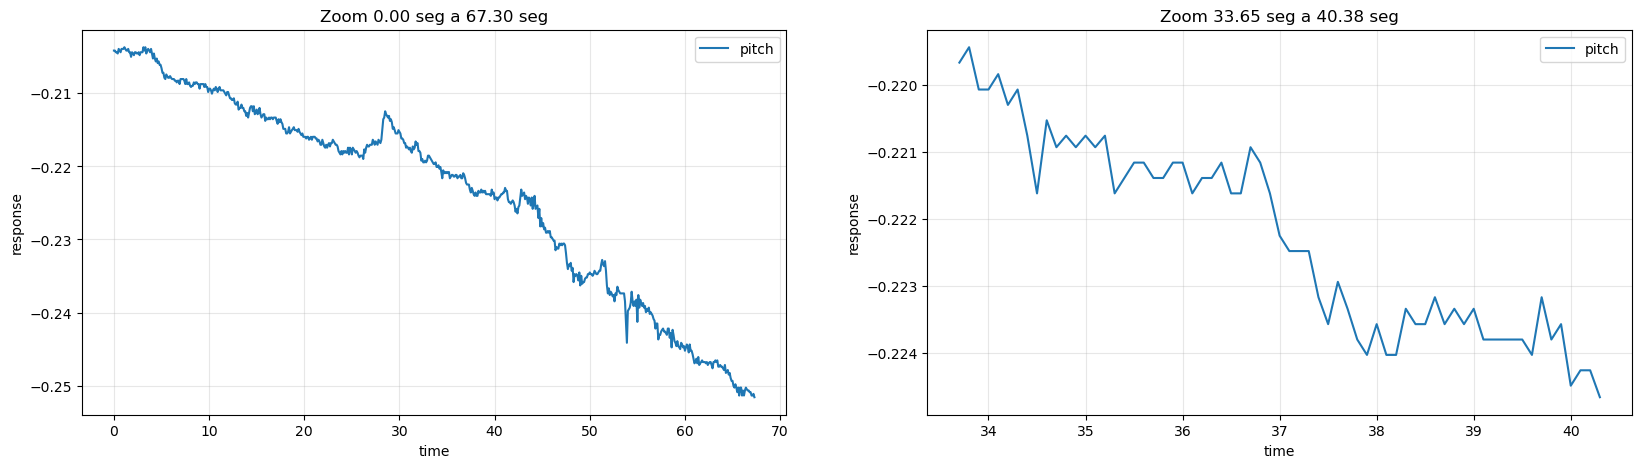

In [37]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [38]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col != 'time'})
df

,time,ref_wx,ref_wz,ref_yaw,ref_q1,ref_sample_time,ref_roll,ref_az,ref_q0,ref_q2,ref_la_pos_mon_d,ref_wy,ref_pitch,ref_ax,ref_q3,ref_ay
0,0.0,0.003031,-0.009672,-40.634167,0.6589,905000000.0,89.32412,-0.1157,0.6673,-0.2453,0.1645,-0.023193,-0.204145,0.03940,-0.2457,-9.788
1,0.1,0.004274,0.000688,-40.639896,0.6589,5000000.0,89.32412,-0.1158,0.6673,-0.2453,0.1647,-0.026769,-0.204145,0.03912,-0.2458,-9.788
2,0.2,-0.005924,0.001382,-40.639896,0.6589,105000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1650,-0.024528,-0.204374,0.03920,-0.2458,-9.788
3,0.3,0.007053,-0.007534,-40.639896,0.6589,205000000.0,89.32412,-0.1155,0.6673,-0.2453,0.1652,-0.030487,-0.204374,0.03921,-0.2458,-9.788
4,0.4,-0.009752,-0.005117,-40.645626,0.6588,305000000.0,89.32412,-0.1157,0.6673,-0.2454,0.1655,-0.034956,-0.204546,0.03936,-0.2458,-9.788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,66.9,0.008021,-0.003244,-42.163964,0.6553,805000000.0,89.32412,-0.1144,0.6643,-0.2543,0.1323,-0.021251,-0.250898,0.04202,-0.2544,-9.788
670,67.0,-0.000432,0.007976,-42.169694,0.6553,905000000.0,89.32412,-0.1144,0.6642,-0.2543,0.1319,-0.025531,-0.251357,0.04224,-0.2544,-9.788
671,67.1,-0.020426,0.015722,-42.169694,0.6552,5000000.0,89.32412,-0.1142,0.6642,-0.2543,0.1316,-0.021056,-0.251357,0.04215,-0.2545,-9.788
672,67.2,0.013178,-0.008371,-42.175423,0.6552,105000000.0,89.32412,-0.1145,0.6642,-0.2543,0.1312,-0.018346,-0.251127,0.04204,-0.2545,-9.788


In [39]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)